# IMPLEMENTACIÓN CONJUNTA

En el presente cuaderno se presenta la implementación conjunta de los métodos ts-MULE (Schlegel et al. 2021) y CONFETTI (Cetina et al. 2026), utilizando una instancia del conjunto de pruebas. Se desarrollaronc códigos para la generación de gráficos para efectuar un análisis conjunto de las explicaciones del modelo, lo que permite contrastar los resultados de ambos métodos, otorgando una expliación más robusta. 

Los códigos se presentan de manera organizada efectuando primero en análisis con ts-MULE y posteriormente con CONFETTI, para finalmente presentar los gráficos de análisis conjunto. En este cuaderno se pueden cargar resultados para cada método obtenido previamente o se puede efectuar el análisis para una instancia desde cero. Las funciones utilizadas se encuentran en los paquetes de datos de `xai_utils/*.py`. 


<u>Referencias:</u>
- Schlegel, U., Lam, D. V., Keim, D. A., & Seebacher, D. (2021). TS-MULE: Local Interpretable Model-Agnostic Explanations for Time Series Forecast Models. Joint European Conference on Machine Learning and Knowledge Discovery in Databases, 5–14. http://arxiv.org/abs/2109.08438
- Cetina, A. G. P., Benguessoum, K., Lourenço, R., & Kubler, S. (2026). Counterfactual Explainable AI (XAI) Method for Deep Learning-Based Multivariate Time Series Classification. Proceedings of the AAAI Conference on Artificial Intelligence, 17393–174000. http://arxiv.org/abs/2511.13237

In [1]:
import numpy as np
import pickle
import sys, os, warnings
import pandas as pd
import matplotlib.pyplot as plt

# Add module tsmule to syspath
print("Current working dir:", os.getcwd())
sys.path.insert(0, 'METHODS/ts-mule')

# Filter out all RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning) 

import logging 
logging.getLogger("stumpy").setLevel(logging.ERROR)

from datetime import datetime
start_ = datetime.now()

Current working dir: C:\Users\asuso\Documents\UTFSM\Doctorado Ing Aplicada\Cursos\INF473 - Introducción XAI\Proyecto\repo


### Cargar resultados guardados de otro Notebook

In [2]:
#Cargar resultados de ts-MULE
try:
    data = np.load('RESULTADOS_TSMULE\\_resultados_tsmule_02.npz')
    resultados_tsmule = {
        'relevance_promedio': data['relevance_promedio'],
        'relevances_all':     data['relevances_all'],
        'x_perturbed':        data['x_perturbed'],
        'x_original':         data['x_original'],
        'mask':               data['mask']
    }
    print('Resutlados de ts-MULE cargados')

except:
    print('No hay resutlados de ts-MULE para cargar')    

Resutlados de ts-MULE cargados


In [ ]:
# Cargar resultados CONFETTI
try:
    with open('RESULTADOS_CONFETTI\\_resultados_cf_02.pkl', 'rb') as f:
        resultados_cf = pickle.load(f)
    print('Resutlados de CONFETTI cargados')
except:
    print('No hay resultados de CONFETTI para cargar')        

### Generar evaluaciones desde cero con ambos métodos

In [3]:
# Cargar Datos
with open('DATA\\xtest_new.pickle', 'rb') as f:
    X_test = pickle.load(f)
with open('DATA\\xtrain_new.pickle', 'rb') as f:
    X_train = pickle.load(f)


In [4]:
#Cargar modelo
import keras
from keras.models import load_model

model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras')

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
# Seleccionar muestra de los datos de test
#m = 1 #ALTA PROBABILIDAD DE INUNDACIÓN ~0.999
#m = 2 #BAJA PROBABILIDAD DE INUNDACIÓN ~0.008
#m = 62 #PROABILIDAD INTERMEDIA ~ 0.5
m = 39 #p~0.77
instance_confetti = X_test[m:m+1]  # serie de tsunami a evaluar
instance_tsmule = X_test[m]
#n_steps, features = X_nuevo.shape
p = model.predict(instance_confetti)
print('Predicción: ',p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
Predicción:  [[0.7744924]]


#### ts-MULE

Saltar esta sección si los datos fueron cargados anteriormente

In [6]:
# Funciones desarrolladas para implementar ts-MULE en el set de datos
from xai_utils.tsmule_analysis import analyze_with_tsmule
from xai_utils.tsmule_plots import plot_relevance_map, plot_original_vs_perturbed, plot_relevance_per_feature, plot_relevance_summary

In [8]:
#valores determinados mediante analisis de convergencia (~30 minutos)
n_runs=300 #300
n_samples=100 #100

resultados_tsmule = analyze_with_tsmule(
    model=model,
    x=instance_tsmule,
    n_runs=n_runs,
    n_samples=n_samples,
    segmentation_method='slopes-sorted',
    feature_names=['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6'],
    save_path='RESULTADOS_TSMULE\\'
)

Calculando relevancia con 3 iteraciones...
  Inicio: 10:32:07


C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.010e-02, tolerance: 7.604e-04
  model = cd_fast.enet_coordinate_descent(
C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.479e-03, tolerance: 6.337e-04
  model = cd_fast.enet_coordinate_descent(


¡Cálculo completado! Fin: 10:34:08


C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.442e-03, tolerance: 7.042e-04
  model = cd_fast.enet_coordinate_descent(


Figura guardada: RESULTADOS_TSMULE\_mapa_relevancia.pdf


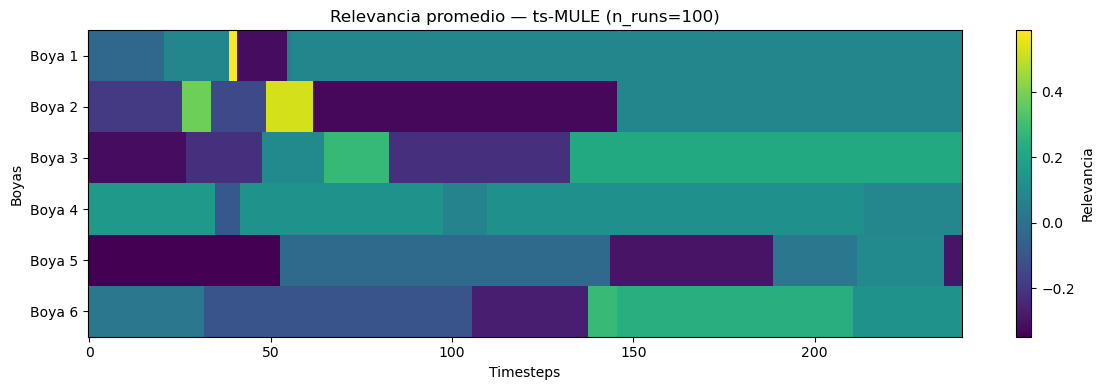

Figura guardada: RESULTADOS_TSMULE\_series_perturbadas.png


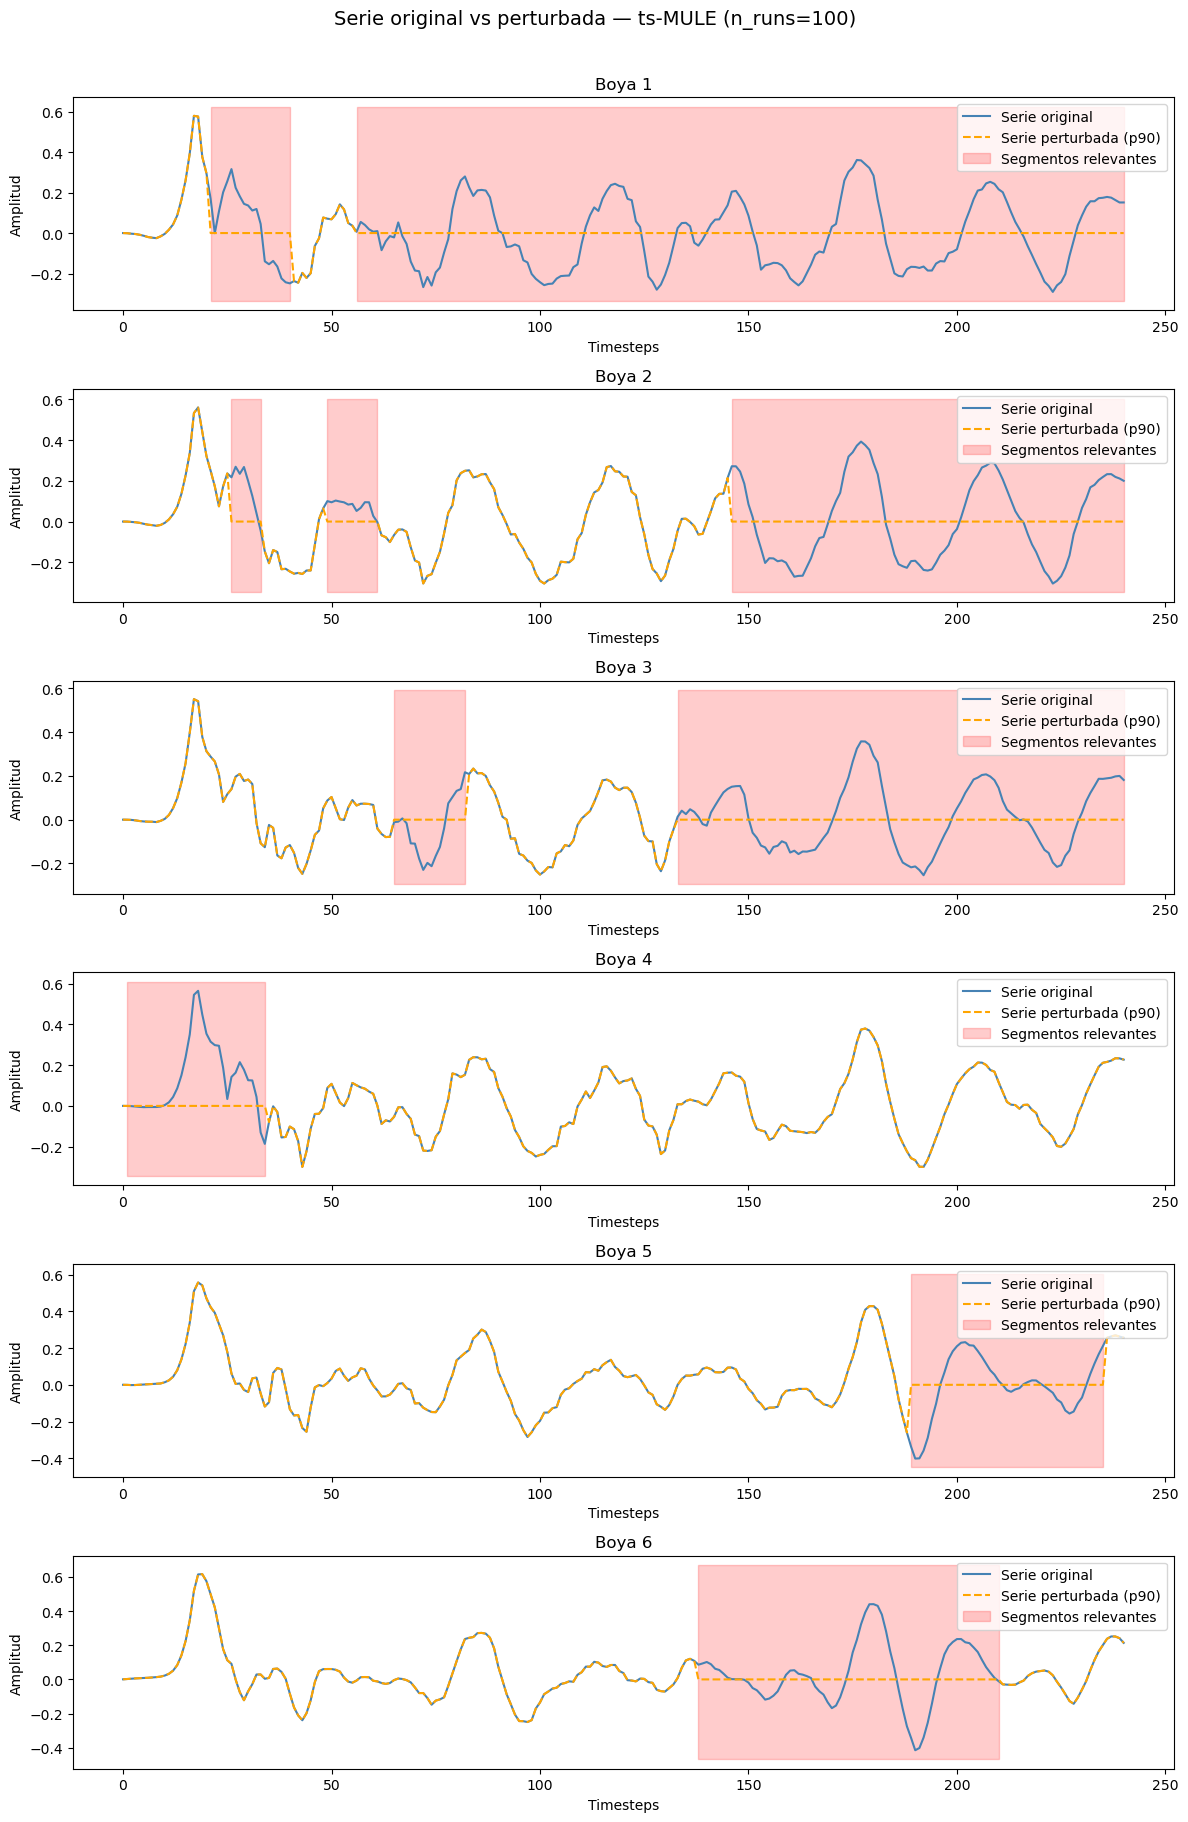

Figura guardada: RESULTADOS_TSMULE\_relevancia_por_boya.png


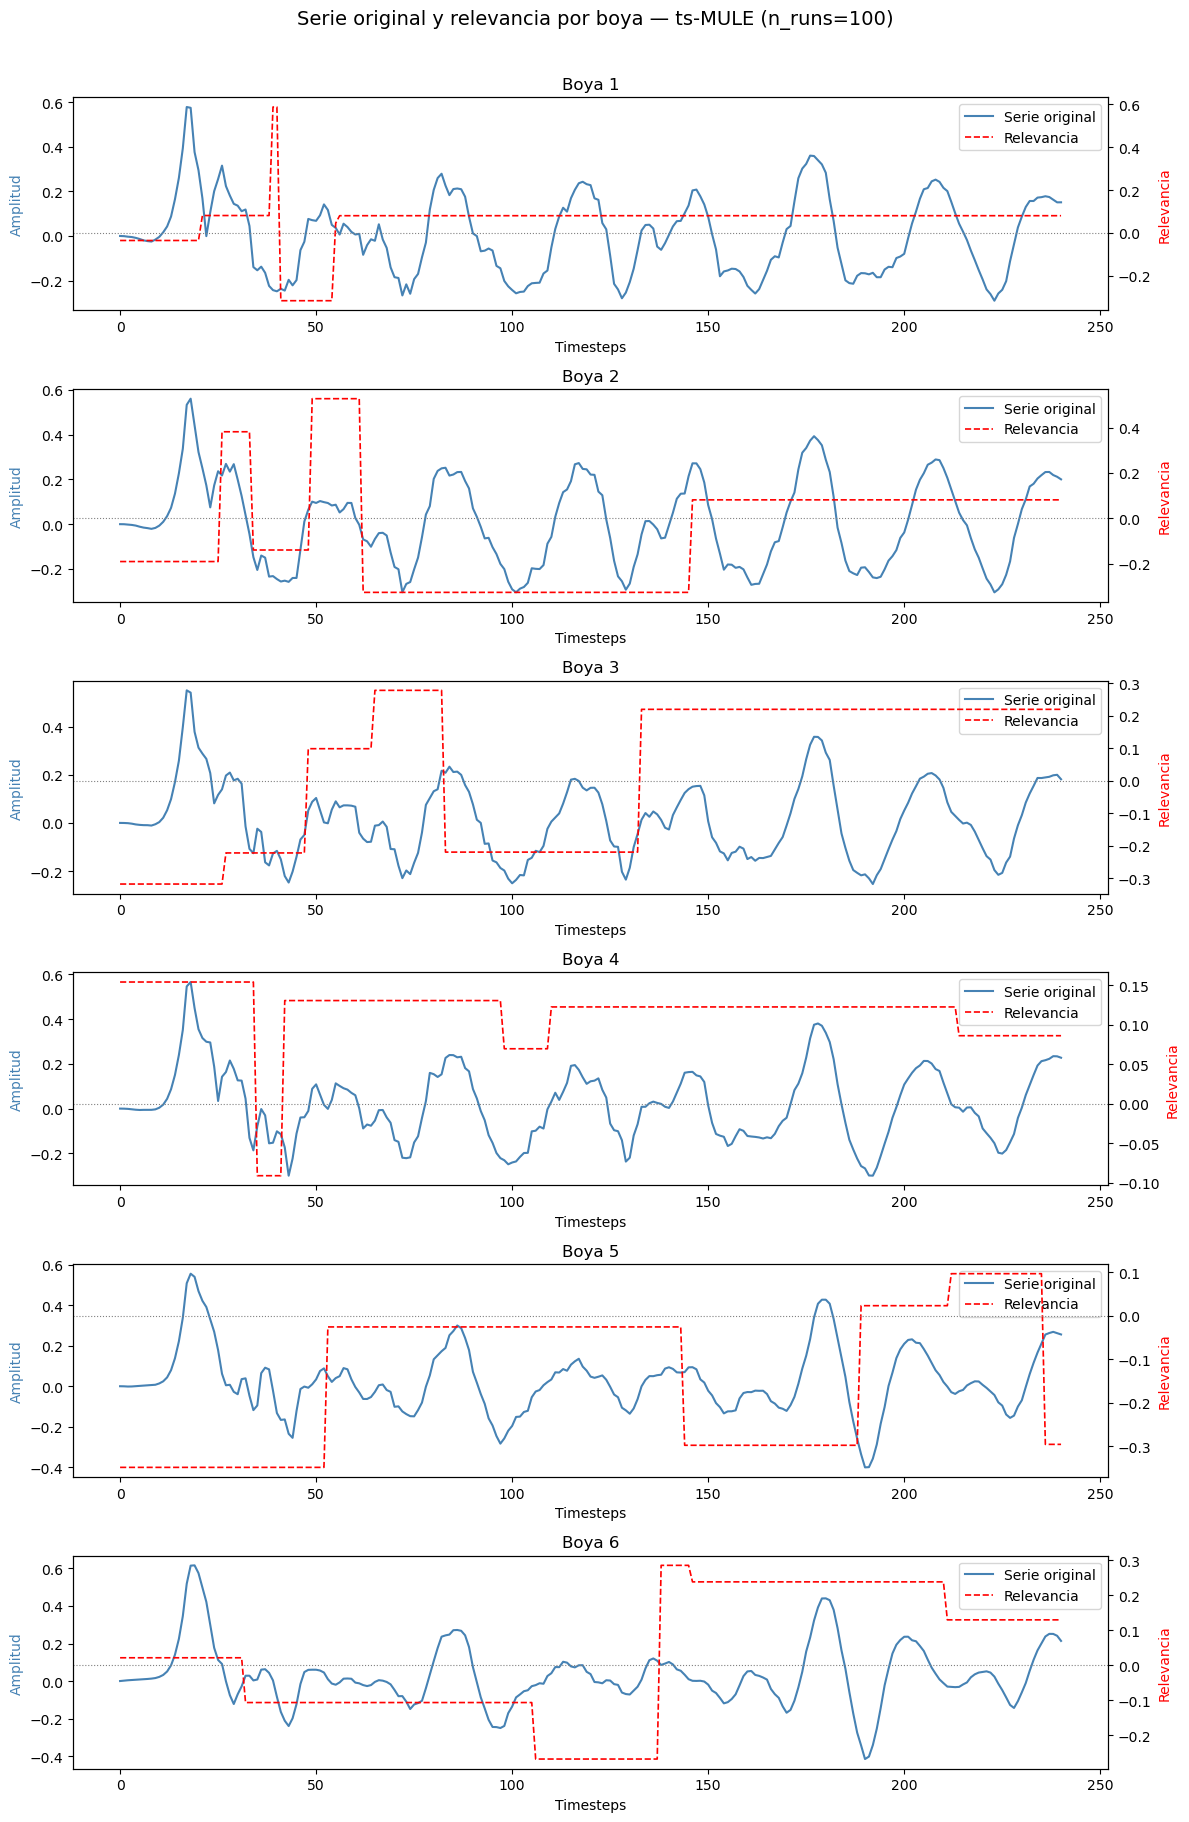

Figura guardada: RESULTADOS_TSMULE\_resumen_relevancia.png


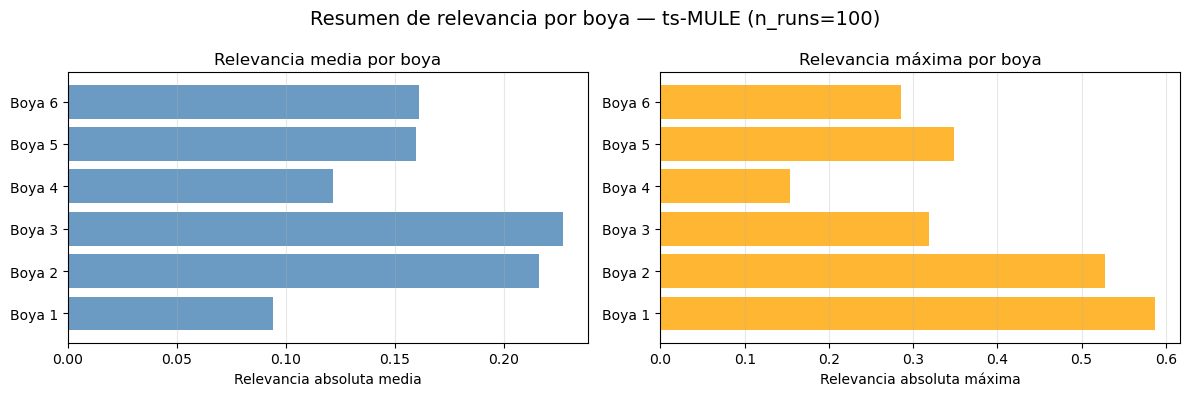

In [10]:
feature_names = ['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6']
save_path_m = 'RESULTADOS_TSMULE\\'

plot_relevance_map(resultados_tsmule, feature_names=feature_names, n_runs=n_runs, save_path=save_path_m)
plot_original_vs_perturbed(resultados_tsmule, feature_names=feature_names, n_runs=n_runs, percentile=90, save_path=save_path_m)
plot_relevance_per_feature(resultados_tsmule, feature_names=feature_names, n_runs=n_runs, save_path=save_path_m)
plot_relevance_summary(resultados_tsmule, feature_names=feature_names, n_runs=n_runs, save_path=save_path_m)

#### CONFETTI

Saltar esta sección si los datos fueron cargados anteriormente

In [11]:
# Funciones desarrolladas para implementar CONFETTI en el set de datos
from xai_utils import analyze_with_confetti
from xai_utils import (plot_best_counterfactual, plot_counterfactuals_by_diff,
                        plot_counterfactuals_by_ts, plot_counterfactual_channels,
                        plot_cf_summary)

In [14]:
#valores determinados mediante analisis de convergencia (~9 minutos)
psize=100 #100
max_gen=200 #200

resultados_cf = analyze_with_confetti(
    model_path_wrapped='MODELS\\transfer_learned_tsunami_classifier_wrapped.keras',
    model_path_original='MODELS\\transfer_learned_tsunami_classifier.keras',
    instance=instance_confetti,
    training_weights_path=None, #'MODELS\\training_weights_resized.npy',
    X_train=X_train,
    n_partitions=5,           # menos segmentos => más rápido
    alpha=0.5,           # restricción de sparsity
    theta=0.51,           # umbral para cambio de clase
    optimize_sparsity=True,  # desactivar para prueba rápida
    population_size=psize,       # Test de convergencia
    maximum_number_of_generations=max_gen,  # Test de convergencia
    feature_names=['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6'],
    save_path='RESULTADOS_CONFETTI\\',
    use_cam_weights=False
)

Cargando modelo original y calculando pesos CAM...
  Inicio: 10:38:20
Usando reference_weights=None

Cargando explainer CONFETTI...

Generando contrafactuales...
  Parámetros: n_partitions=5, alpha=0.5, theta=0.51, optimize_sparsity=True, population_size=100
¡Generación completada! Fin: 10:48:56
Contrafactuales generados: 34
Resultados guardados en: RESULTADOS_CONFETTI\_resultados_cf.pkl


Figura guardada: RESULTADOS_CONFETTI\_mejor_cf.png


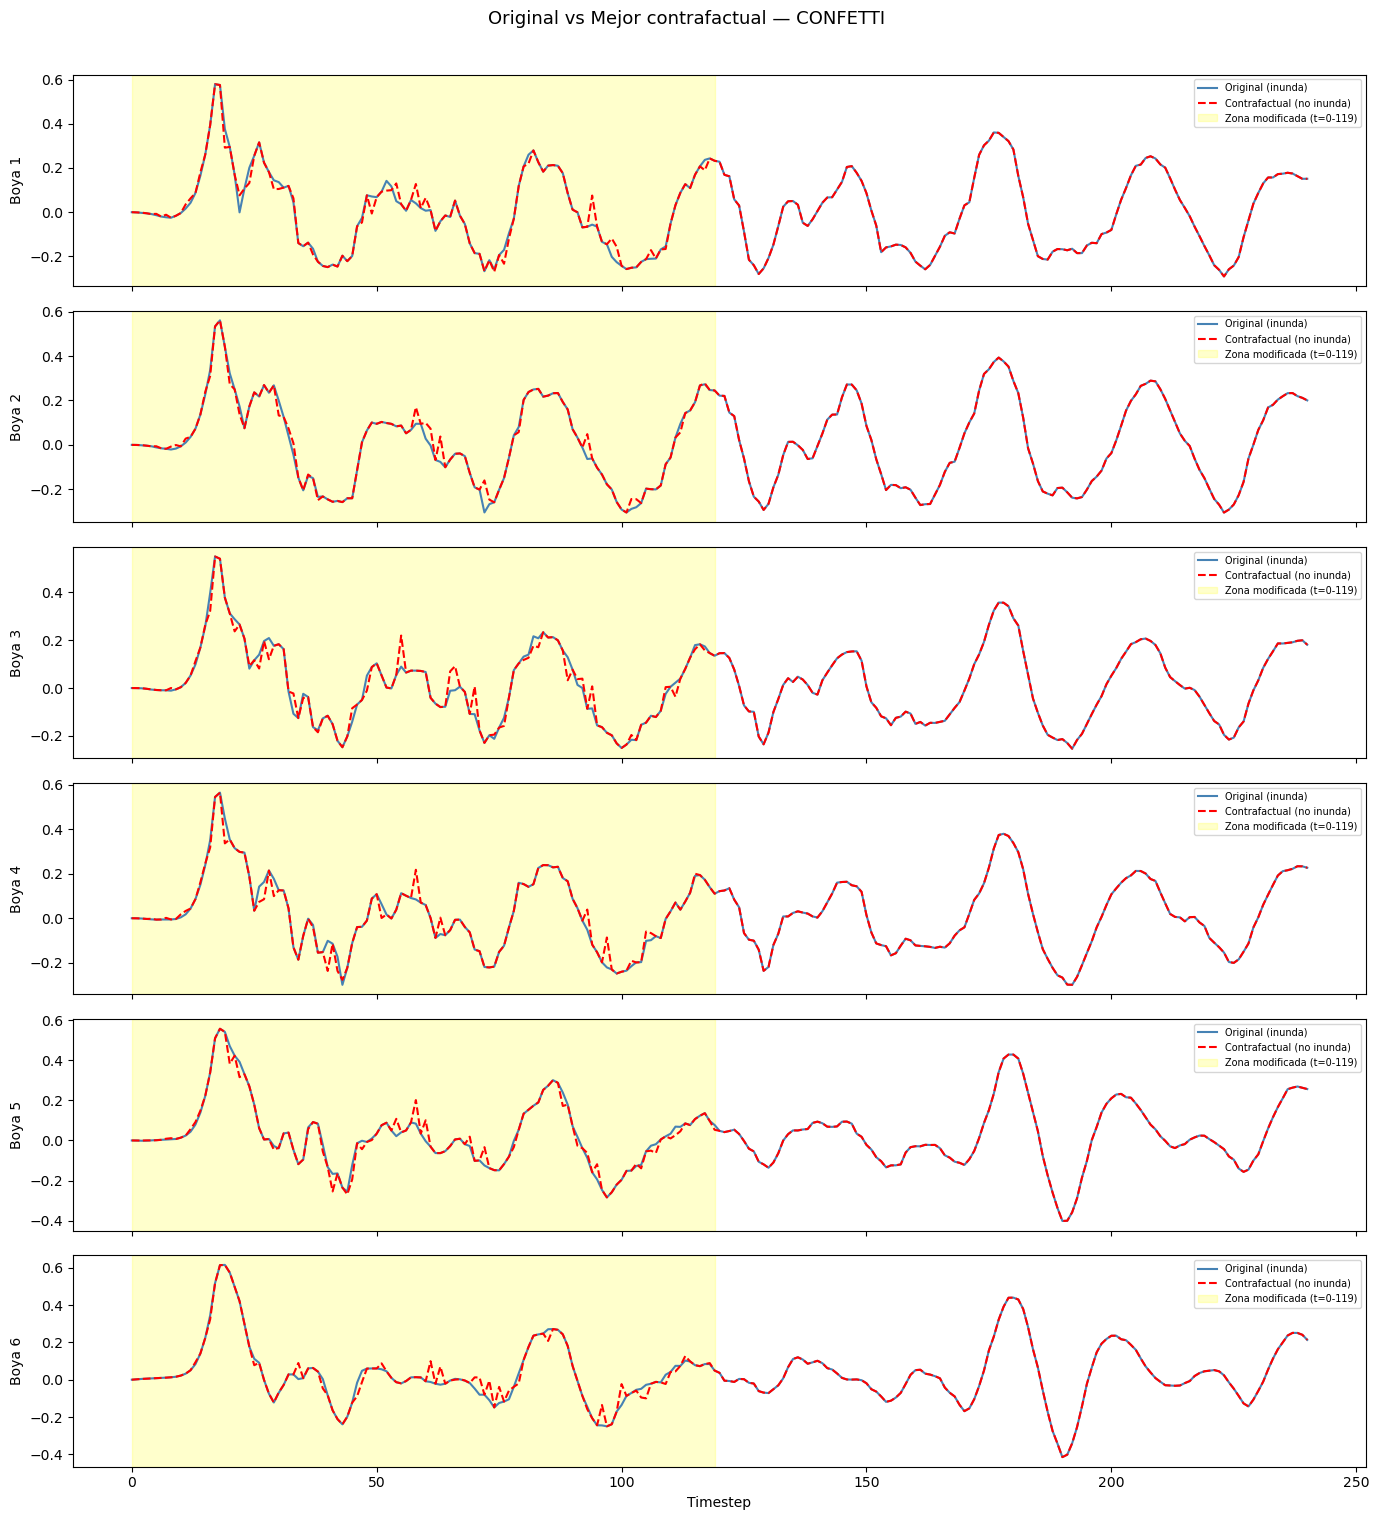

Figura guardada: RESULTADOS_CONFETTI\_cf_por_diff.png


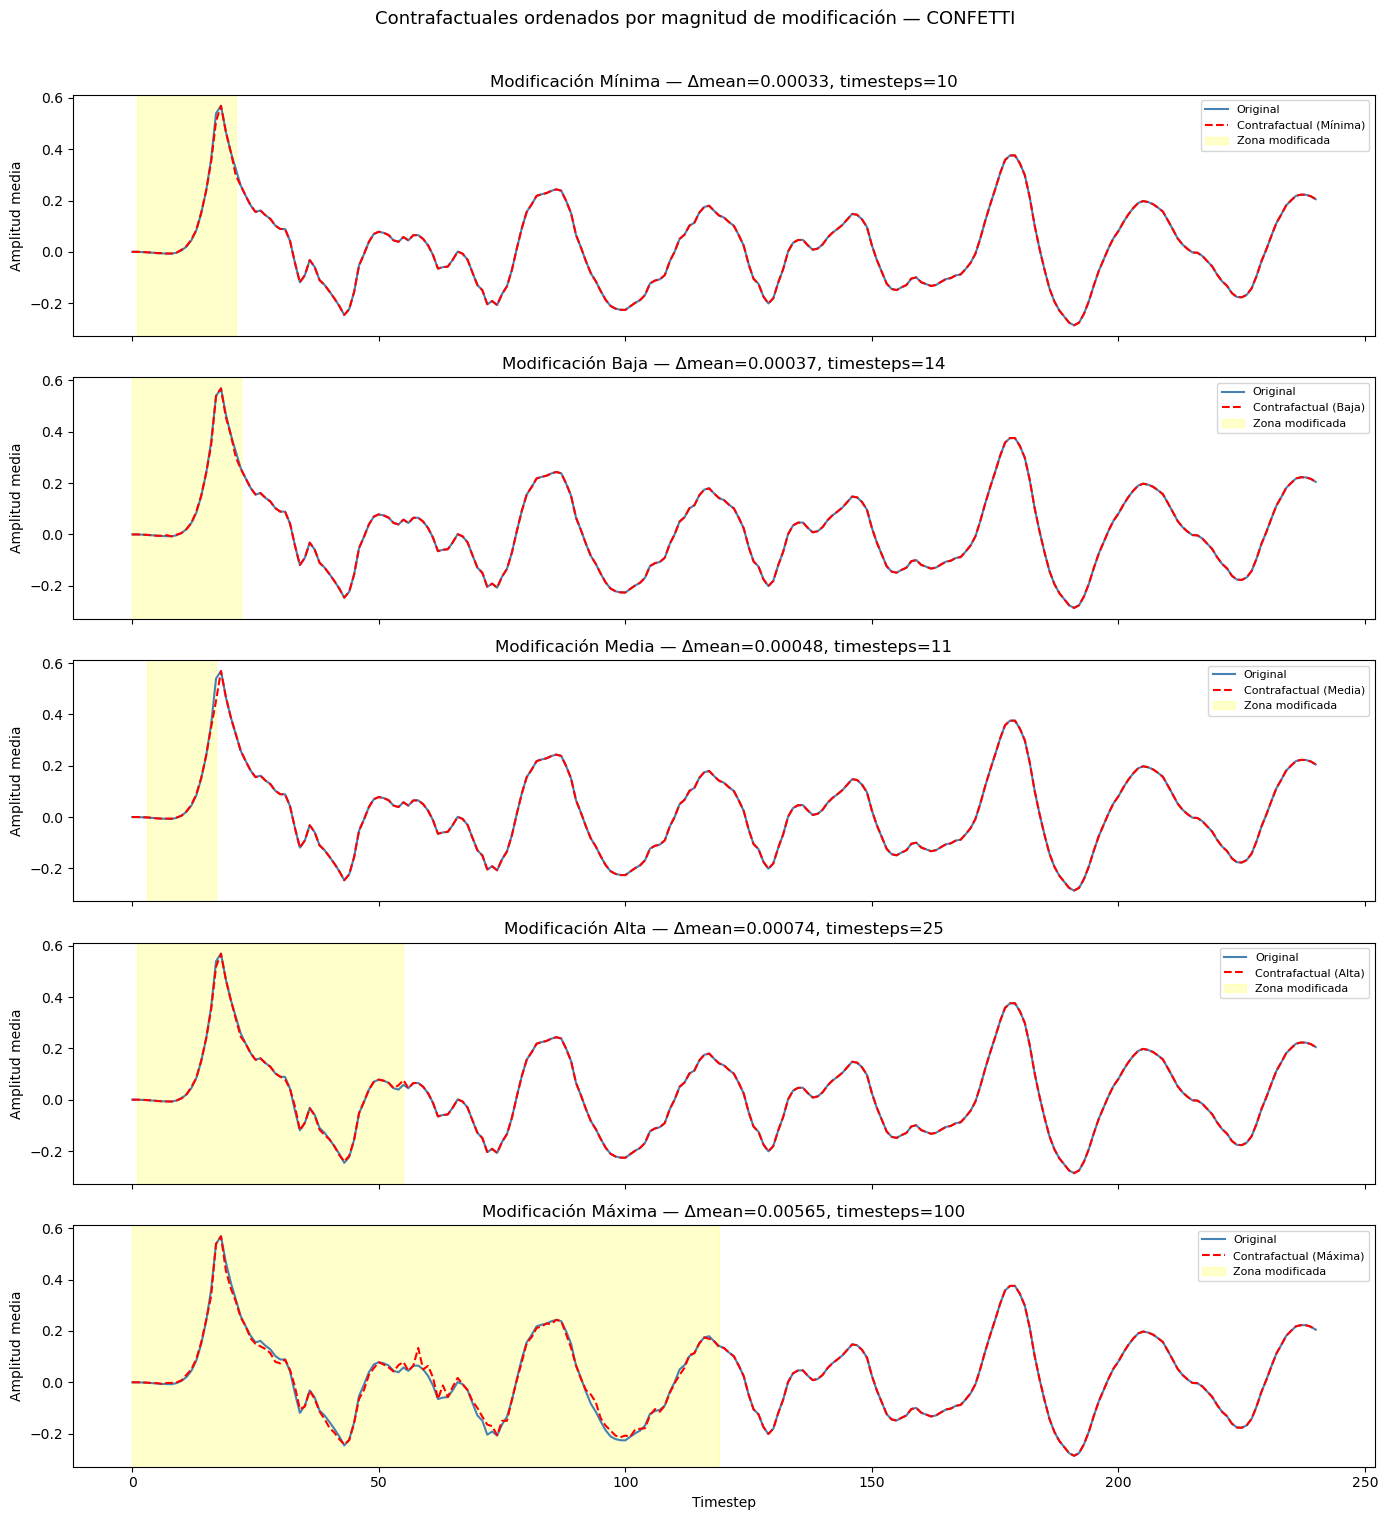

Figura guardada: RESULTADOS_CONFETTI\_cf_por_ts.png


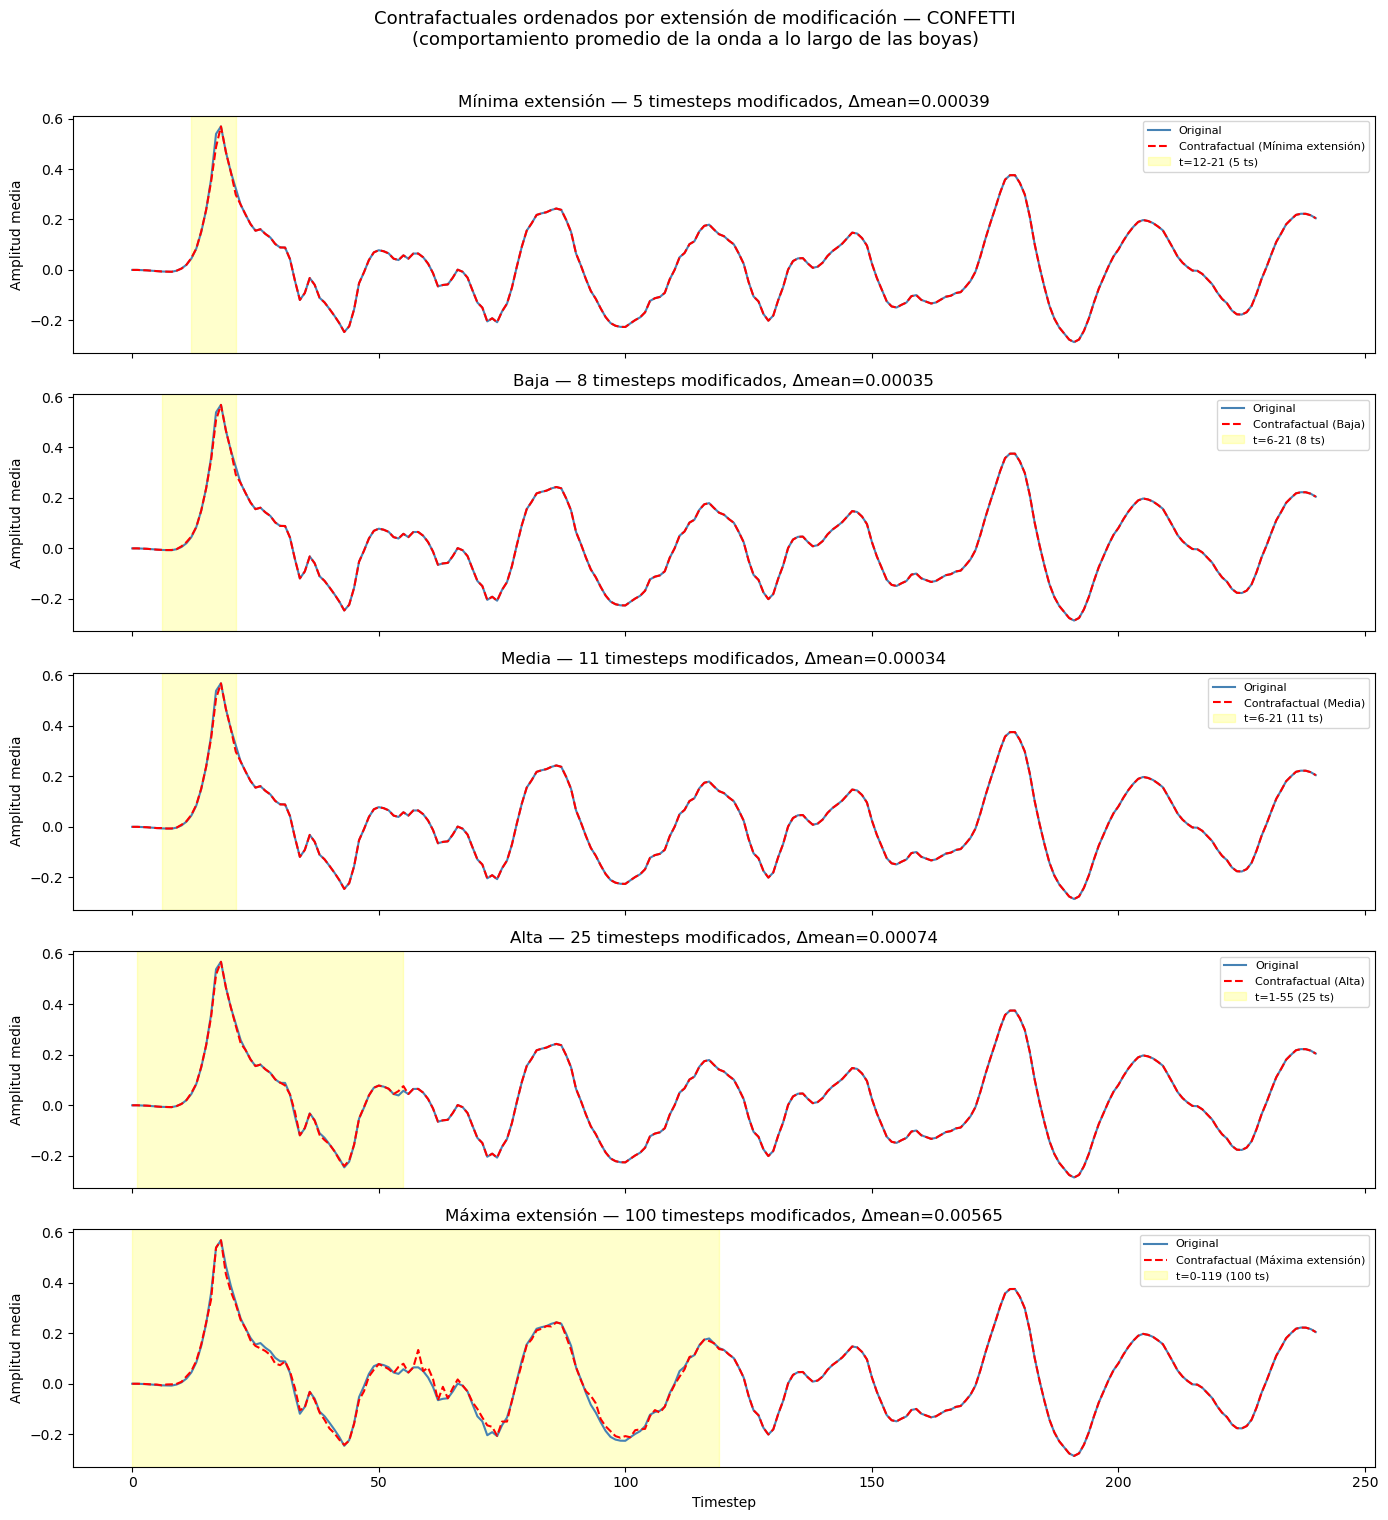

In [ ]:
plot_best_counterfactual(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactuals_by_diff(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactuals_by_ts(resultados_cf, save_path='RESULTADOS_CONFETTI\\')
plot_counterfactual_channels(resultados_cf, cf_index=0, cf_sorted_key='ts', save_path='RESULTADOS_CONFETTI\\')
plot_cf_summary(resultados_cf, save_path='RESULTADOS_CONFETTI\\')

#### Análisis conjunto

In [12]:
# Verificación de los resultados cargaddos para cada método
print('Resultados ts-MULE: ',resultados_tsmule.keys())
print('Resultados CONFETTI: ',resultados_cf.keys())

Resultados ts-MULE:  dict_keys(['relevance_promedio', 'relevances_all', 'x_perturbed', 'x_original', 'mask'])
Resultados CONFETTI:  dict_keys(['cf_stats', 'cf_stats_sorted_diff', 'cf_stats_sorted_ts', 'cf_stats_sorted_region', 'best_cf', 'instance', 'feature_names', 'results'])


In [13]:
from xai_utils import (plot_comparison_summary, 
                        plot_comparison_regions,
                        plot_comparison_heatmaps)

feature_names = ['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6']
save_path = 'RESULTADOS_COMPARACION\\'

Figura guardada: RESULTADOS_COMPARACION\_comparacion_resumen.png


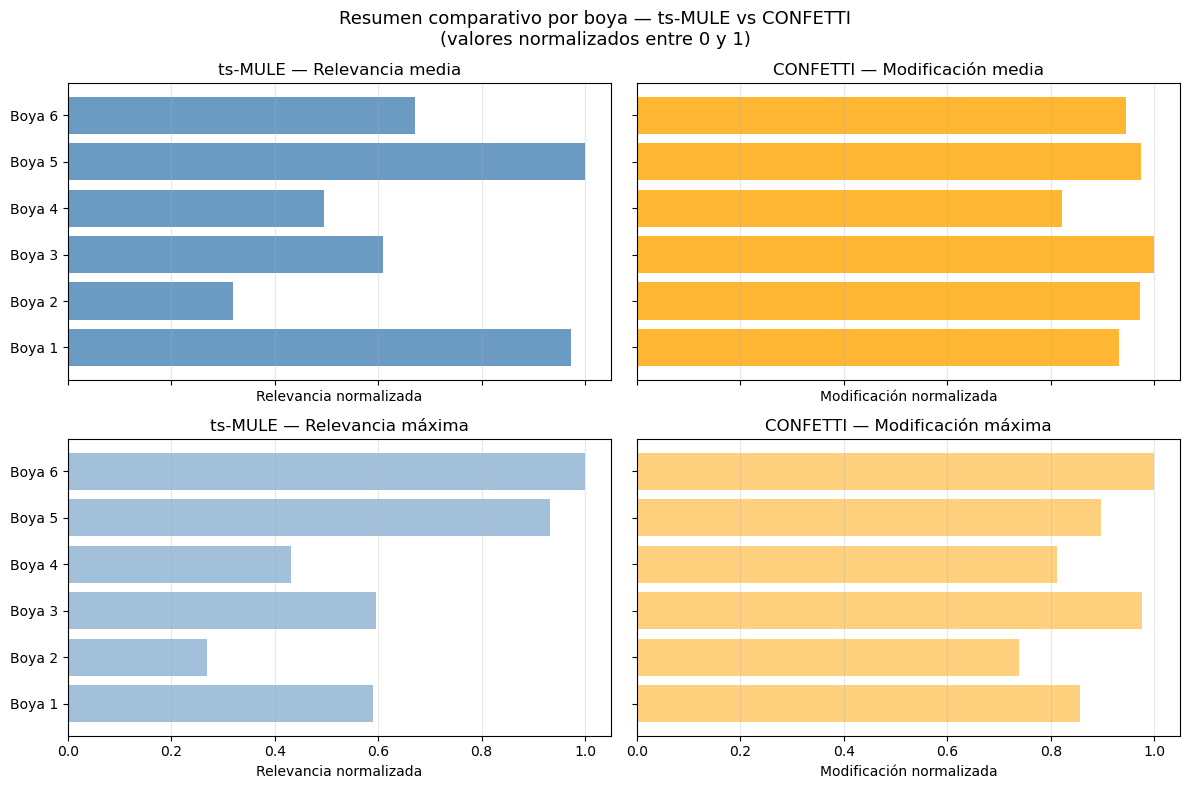

Figura guardada: RESULTADOS_COMPARACION\_comparacion_regiones.png


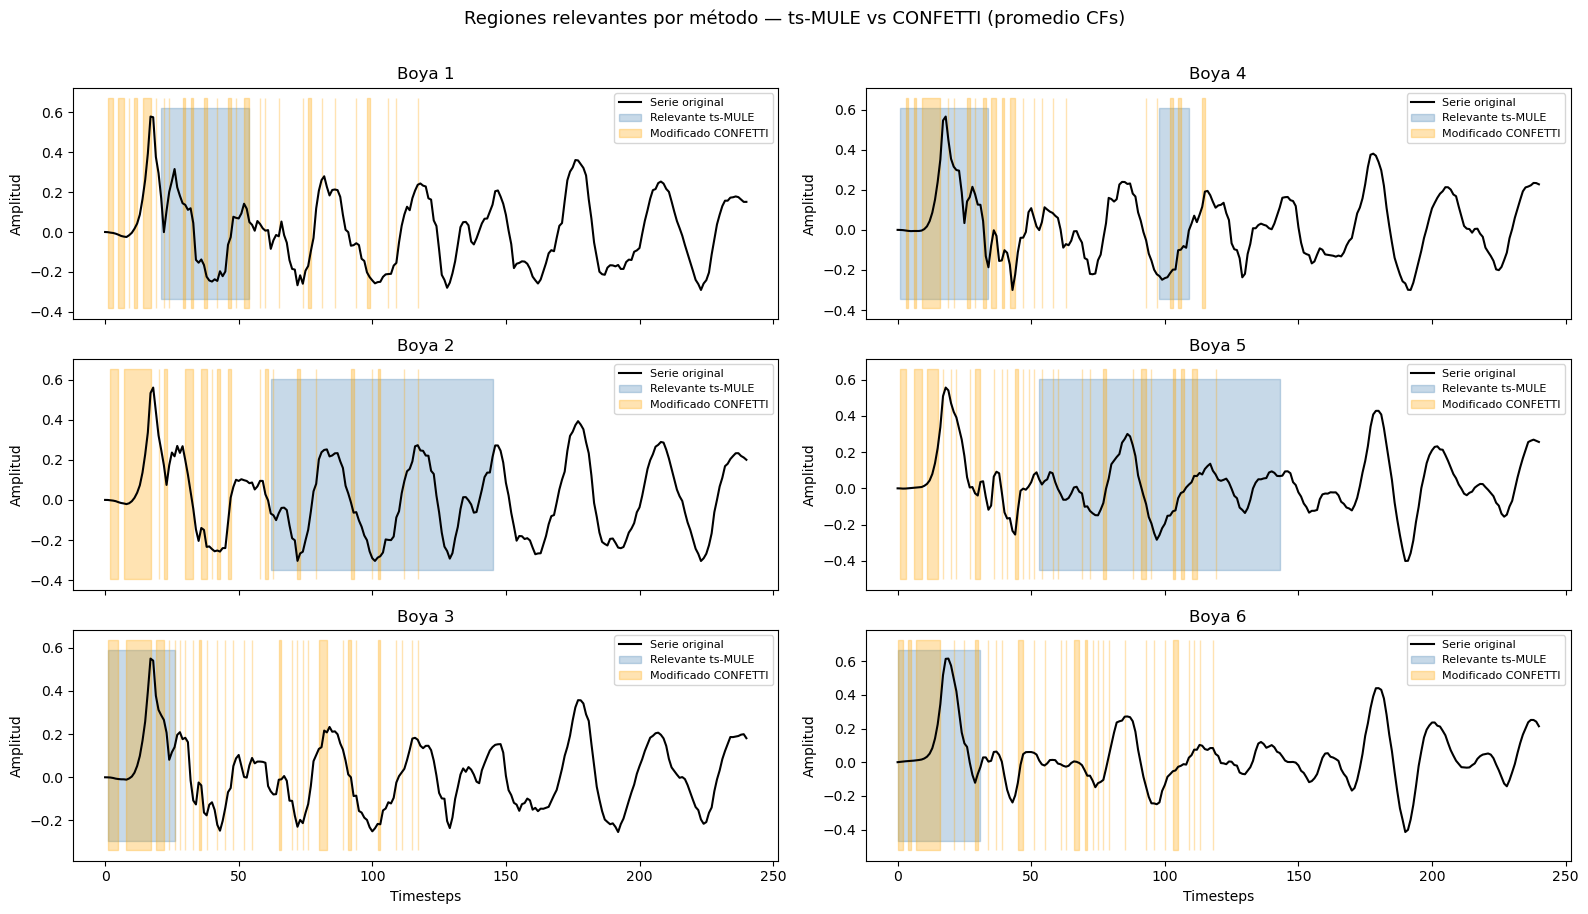

Figura guardada: RESULTADOS_COMPARACION\_comparacion_heatmaps.png


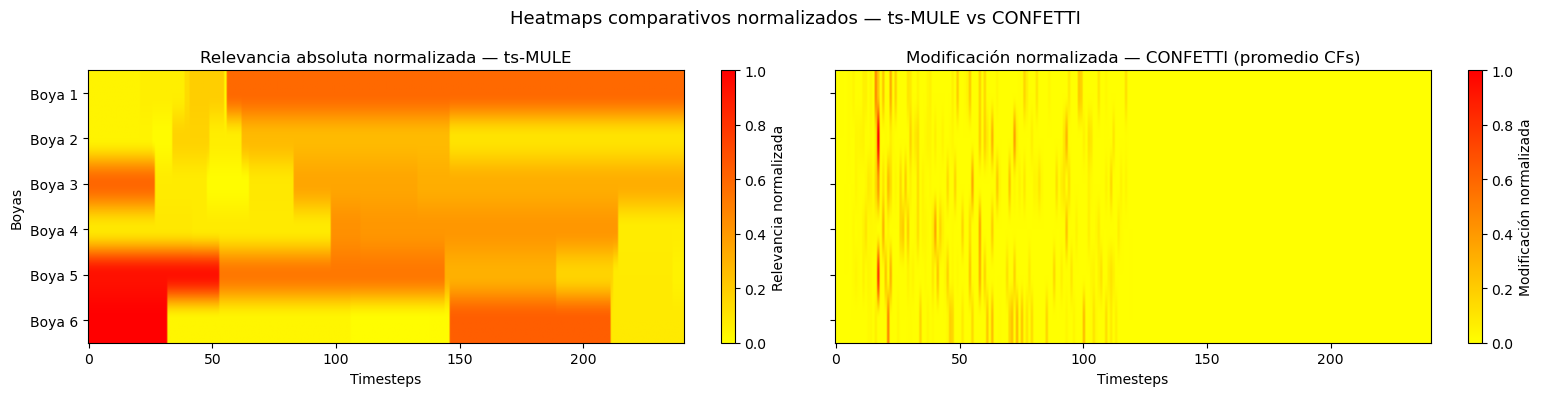

In [14]:
plot_comparison_summary(resultados_tsmule, resultados_cf, 
                        feature_names=feature_names, save_path=save_path)
plot_comparison_regions(resultados_tsmule, resultados_cf, 
                        cf_source='mean', feature_names=feature_names, save_path=save_path)
plot_comparison_heatmaps(resultados_tsmule, resultados_cf, 
                         cf_source='mean', feature_names=feature_names, save_path=save_path, cmap='autumn_r')

In [15]:
end_ = datetime.now()
print(f'Terminé de ejcutarse todo, tardando {str(end_-start_)}')

Terminé de ejcutarse todo, tardando 0:46:57.996704
